In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
path = "../../data/Epileptic Seizure Recognition.csv"
df = pd.read_csv(path)

In [4]:
df.head(3)

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5


- all subjects falling in classes 2,3,4, and 5 are subjects who did not have an epileptic seizure
- only subjects in class 1 have an epileptic seizure

In [5]:
df['y'].value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

visualisation

In [6]:
df[df['y'] == 1]

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
8,X19.V1.874,-278,-246,-215,-191,-177,-167,-157,-139,-118,...,-400,-379,-336,-281,-226,-174,-125,-79,-40,1
11,X21.V1.724,-167,-230,-280,-315,-338,-369,-405,-392,-298,...,423,434,416,374,319,268,215,165,103,1
20,X23.V1.964,410,451,491,541,581,641,736,757,692,...,415,428,463,510,562,607,667,748,763,1
22,X11.V1.134,-264,-189,-117,-45,20,70,111,143,161,...,-231,-221,-248,-321,-444,-530,-548,-536,-486,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11487,X17.V1.874,98,107,121,143,166,184,185,174,153,...,-31,11,48,77,95,107,111,110,119,1
11488,X20.V1.494,267,409,450,416,334,248,173,113,67,...,413,288,173,76,7,-27,-46,-58,-67,1
11490,X14.V1.404,-22,-64,-121,-201,-292,-336,-398,-527,-773,...,183,-152,-499,-577,-415,-223,-88,-18,-61,1
11492,X13.V1.624,-27,-53,-84,-104,-131,-171,-199,-203,-177,...,-127,-114,-99,-79,-56,-28,-14,-8,-12,1


<Axes: >

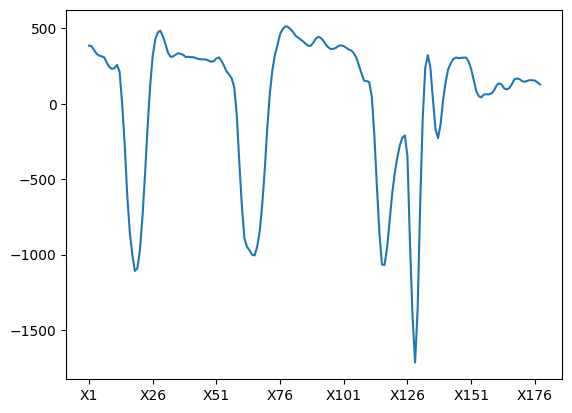

In [7]:
df[df['y'] == 1].iloc[0, 1:-1].plot()

<Axes: >

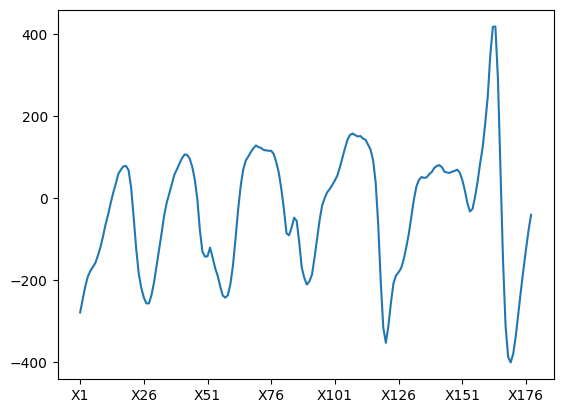

In [9]:
df[df['y'] == 1].iloc[1, 1:-1].plot()

<Axes: >

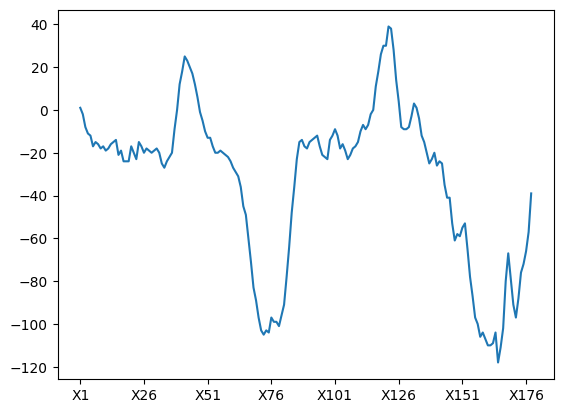

In [8]:
df[df['y'] == 2].iloc[0, 1:-1].plot()

<Axes: >

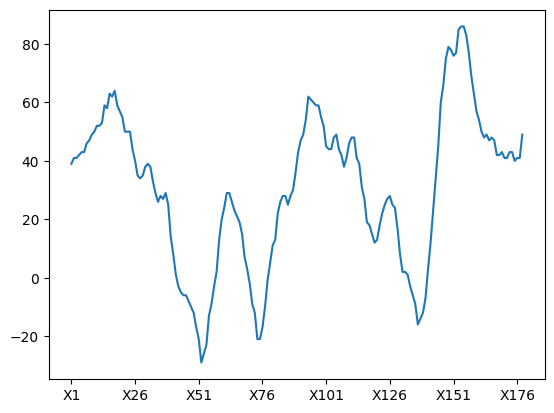

In [11]:
df[df['y'] == 2].iloc[2, 1:-1].plot()

<Axes: >

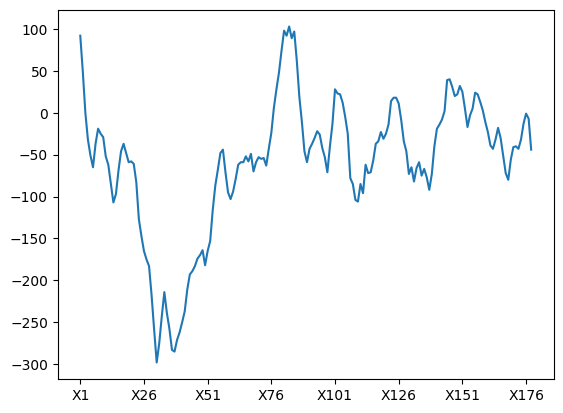

In [12]:
df[df['y'] == 3].iloc[0, 1:-1].plot()

<Axes: >

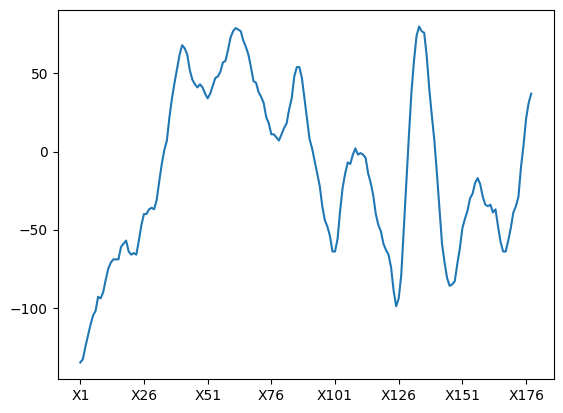

In [13]:
df[df['y'] == 3].iloc[1, 1:-1].plot()

need to relabel and build a binary classifier of:
- epileptic seizures or not
- 1 is positive every other label is negative, 0

In [14]:
df_ = df.copy()
df_.shape

(11500, 180)

In [15]:
df_['y'] = df_['y'].apply(lambda x: 0 if x != 1 else x)

In [16]:
df_.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,0
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,0
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,0
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,0


There's more negatives than positives...need to balance these out for the dataset

In [17]:
df_['y'].value_counts()

y
0    9200
1    2300
Name: count, dtype: int64

In [18]:
positives = df_[df_['y']==1]

In [19]:
negatives = df_[df_['y'] == 0]

In [20]:
negatives.index

Index([    0,     2,     3,     4,     5,     6,     7,     9,    10,    12,
       ...
       11485, 11486, 11489, 11491, 11493, 11494, 11495, 11497, 11498, 11499],
      dtype='int64', length=9200)

In [24]:
negative_indices = negatives.index.tolist()

In [25]:
negative_indices

[0,
 2,
 3,
 4,
 5,
 6,
 7,
 9,
 10,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 21,
 25,
 26,
 28,
 29,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 53,
 54,
 55,
 56,
 57,
 59,
 60,
 61,
 62,
 63,
 64,
 66,
 67,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 83,
 84,
 85,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 101,
 102,
 103,
 104,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 132,
 133,
 134,
 136,
 137,
 138,
 139,
 140,
 142,
 143,
 145,
 146,
 147,
 148,
 150,
 151,
 152,
 153,
 154,
 155,
 157,
 158,
 161,
 162,
 163,
 166,
 167,
 168,
 170,
 172,
 173,
 175,
 177,
 180,
 181,
 182,
 184,
 185,
 186,
 187,
 188,
 189,
 191,
 192,
 193,
 194,
 195,
 196,
 197,
 198,
 199,
 201,
 202,
 204,
 205,
 206,
 207,
 209,
 211,
 212,
 213,
 214,
 215,
 216,
 217,
 218,
 220,
 224,
 225,
 226,
 228,
 229,

In [26]:
np.random.seed(42)
# need to shuffle the negative indices
np.random.shuffle(negative_indices)

In [28]:
# picking only 2300 of the negative indices
sel_negative_indices = negative_indices[:2300]

In [29]:
sel_negatives = negatives.loc[sel_negative_indices,:]

In [33]:
# combine both into one dataframe
master_df = pd.concat([positives, sel_negatives], axis=0)

In [34]:
master_df.head(3)

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
8,X19.V1.874,-278,-246,-215,-191,-177,-167,-157,-139,-118,...,-400,-379,-336,-281,-226,-174,-125,-79,-40,1
11,X21.V1.724,-167,-230,-280,-315,-338,-369,-405,-392,-298,...,423,434,416,374,319,268,215,165,103,1


In [35]:
# need to shuffle the dataframe
np.random.seed(42)
master_df_indices = master_df.index.tolist()
np.random.shuffle(master_df_indices)
master_df = master_df.loc[master_df_indices, :]

In [37]:
master_df.head(5)

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
707,X18.V1.60,-6,-7,-16,-40,-66,-80,-75,-62,-50,...,-62,-62,-66,-79,-86,-97,-98,-100,-96,0
7183,X10.V1.33,-26,-33,-57,-55,-88,-66,-42,-38,-8,...,-20,-19,-7,-2,10,7,-4,-24,-55,0
8943,X11.V1.45,-31,-13,7,-9,-15,-21,-22,-15,-26,...,0,-4,-13,-31,-35,-54,-59,-59,-57,0
346,X19.V1.934,35,-23,-55,-97,-188,-358,-548,-684,-721,...,262,341,387,375,337,259,185,131,92,1
9255,X5.V1.484,314,256,236,395,590,631,41,-984,-1775,...,-213,-39,111,268,375,439,449,425,373,1


In [39]:
from sklearn.model_selection import train_test_split

In [40]:
# train, val, test splits
train_df, test_df = train_test_split(master_df, test_size=0.2, random_state=42, shuffle=True, stratify=master_df['y'])
train_df_, val_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['y'])

build out the tensor dataset

In [41]:
from torch.utils.data import TensorDataset

In [43]:
train_df.head(2)

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
1715,X21.V1.524,249,250,243,240,233,234,230,226,219,...,-88,-96,-97,-107,-108,-116,-117,-118,-113,1
6937,X3.V1.732,9,8,6,6,0,2,2,-1,-5,...,-26,-25,-20,-16,-18,-20,-25,-29,-28,0


In [44]:
x_train, y_train = torch.tensor(train_df_.iloc[:, 1:-1].values), torch.tensor(train_df_['y'].values)
x_val, y_val = torch.tensor(val_df.iloc[:, 1:-1].values), torch.tensor(val_df['y'].values)
x_test, y_test = torch.tensor(test_df.iloc[:, 1:-1].values), torch.tensor(test_df['y'].values)

In [45]:
train_dataset = TensorDataset(x_train,y_train)
val_dataset = TensorDataset(x_val,y_val)
test_dataset = TensorDataset(x_test, y_test)

In [47]:
from torch.utils.data import DataLoader

In [48]:
train_dl = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dl = DataLoader(val_dataset, batch_size=64)
test_dl = DataLoader(test_dataset, batch_size=64)

Ok..
- modelling now
- its a binary classification problem so, going to be using the binary cross entropy with logits loss
- going to stick with a vgg style based cnn model